# ResNet50 Training Notebook

This notebook trains a ResNet50 transfer-learning model for the LemoScan-AI citrus leaf dataset.

The workflow is:
1. Load the train, validation, and test folders.
2. Save the class index mapping.
3. Train a classifier head while the ResNet50 base is frozen.
4. Fine-tune the top ResNet50 layers with a smaller learning rate.
5. Evaluate the best saved model on the test set.

## 1. Imports and Configuration

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Required training settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Exact dataset classes. This order controls the saved class index mapping.
CLASS_NAMES = [
    'Algal leaf spot',
    'Black spot',
    'Citrus canker',
    'Citrus pest',
    'Greening',
    'Healthy leaf',
]

# The notebook can be run from the project root or from the training folder.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / 'dataset'
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'val'
TEST_DIR = DATASET_DIR / 'test'

TRAINING_DIR = PROJECT_ROOT / 'training'
MODEL_DIR = PROJECT_ROOT / 'model'
CLASS_INDICES_PATH = TRAINING_DIR / 'class_indices.json'
BEST_MODEL_PATH = MODEL_DIR / 'resnet_best_model.keras'

TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Training data:', TRAIN_DIR)
print('Validation data:', VAL_DIR)
print('Test data:', TEST_DIR)
print('Best model path:', BEST_MODEL_PATH)
print('Class indices path:', CLASS_INDICES_PATH)

Project root: e:\LemoScan-AI
Training data: e:\LemoScan-AI\dataset\train
Validation data: e:\LemoScan-AI\dataset\val
Test data: e:\LemoScan-AI\dataset\test
Best model path: e:\LemoScan-AI\model\resnet_best_model.keras
Class indices path: e:\LemoScan-AI\training\class_indices.json


## 2. Check Dataset Folders

This cell confirms that the train, validation, and test folders contain the exact class folders expected by the project.

In [3]:
for split_name, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    if not split_dir.exists():
        raise FileNotFoundError(f'Missing dataset split folder: {split_dir}')

    found_classes = sorted([path.name for path in split_dir.iterdir() if path.is_dir()])
    expected_classes = sorted(CLASS_NAMES)
    print(f'{split_name}:', found_classes)

    if found_classes != expected_classes:
        raise ValueError(
            f'{split_name} folder classes do not match expected classes.\n'
            f'Expected: {expected_classes}\nFound: {found_classes}'
        )

train: ['Algal leaf spot', 'Black spot', 'Citrus canker', 'Citrus pest', 'Greening', 'Healthy leaf']
val: ['Algal leaf spot', 'Black spot', 'Citrus canker', 'Citrus pest', 'Greening', 'Healthy leaf']
test: ['Algal leaf spot', 'Black spot', 'Citrus canker', 'Citrus pest', 'Greening', 'Healthy leaf']


## 3. Load Train, Validation, and Test Data

`image_dataset_from_directory` reads images directly from the class folders. The `class_names` argument locks the class order so every run uses the same label mapping.

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Class names:', train_ds.class_names)

Found 1433 files belonging to 6 classes.
Found 305 files belonging to 6 classes.
Found 312 files belonging to 6 classes.
Class names: ['Algal leaf spot', 'Black spot', 'Citrus canker', 'Citrus pest', 'Greening', 'Healthy leaf']


## 4. Save Class Index Mapping

The saved JSON file maps class folder names to the numeric labels used during training.

In [5]:
class_indices = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}

with CLASS_INDICES_PATH.open('w', encoding='utf-8') as file:
    json.dump(class_indices, file, indent=4)

print(json.dumps(class_indices, indent=4))
print('Saved class indices to:', CLASS_INDICES_PATH)

{
    "Algal leaf spot": 0,
    "Black spot": 1,
    "Citrus canker": 2,
    "Citrus pest": 3,
    "Greening": 4,
    "Healthy leaf": 5
}
Saved class indices to: e:\LemoScan-AI\training\class_indices.json


## 5. Apply ResNet50 Preprocessing

ResNet50 expects inputs preprocessed with `tensorflow.keras.applications.resnet50.preprocess_input`. This converts RGB image batches into the format used by the original ResNet50 model.

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_for_resnet(images, labels):
    images = preprocess_input(images)
    return images, labels

train_ds_prepared = train_ds.map(preprocess_for_resnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_prepared = val_ds.map(preprocess_for_resnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_prepared = test_ds.map(preprocess_for_resnet, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

## 6. Build the ResNet50 Transfer Learning Model

The ResNet50 base starts with ImageNet weights. The classifier head is trained for this citrus leaf classification task.

In [7]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_average_pooling')(x)
x = layers.BatchNormalization(name='batch_normalization')(x)
x = layers.Dropout(0.35, name='dropout')(x)
outputs = layers.Dense(len(CLASS_NAMES), activation='softmax', name='predictions')(x)

model = keras.Model(inputs, outputs, name='resnet50_citrus_classifier')
model.summary()

Model: "resnet50_citrus_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,198 (90.06 MB)

 Trainable params: 16,390 (64.02 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 7. Training Callbacks

These callbacks save the best validation model, stop training when validation performance stops improving, and lower the learning rate when progress slows.

In [8]:
callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

## 8. Stage 1: Train the Classifier Head

In this stage, the ResNet50 base is frozen and only the new classifier head learns.

In [9]:
STAGE_1_EPOCHS = 20

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

history_stage_1 = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=STAGE_1_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5542 - loss: 1.3564
Epoch 1: val_accuracy improved from None to 0.75738, saving model to e:\LemoScan-AI\model\resnet_best_model.keras

Epoch 1: finished saving model to e:\LemoScan-AI\model\resnet_best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7020 - loss: 0.8957 - val_accuracy: 0.7574 - val_loss: 0.6798 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8974 - loss: 0.2952
Epoch 2: val_accuracy improved from 0.75738 to 0.92131, saving model to e:\LemoScan-AI\model\resnet_best_model.keras

Epoch 2: finished saving model to e:\LemoScan-AI\model\resnet_best_model.keras
45/45 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9002 - loss: 0.2805 - val_accuracy: 0.9213 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9209 - loss: 0.2288
Epoch 3: val_accuracy improved from 0.92131 to 0.93443, saving model to e:\LemoSc

## 9. Stage 2: Fine-Tune Top ResNet50 Layers

Now the top part of ResNet50 is unfrozen and trained with a much smaller learning rate. Earlier layers stay frozen because they contain general image features.

In [10]:
base_model.trainable = True

# Fine-tune only the top layers of ResNet50.
FINE_TUNE_LAYERS = 30
fine_tune_at = max(0, len(base_model.layers) - FINE_TUNE_LAYERS)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Total ResNet50 layers: {len(base_model.layers)}')
print(f'Fine-tuning from layer index: {fine_tune_at}')
print(f'Trainable ResNet50 layers: {sum(layer.trainable for layer in base_model.layers)}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

STAGE_2_EPOCHS = 20
total_epochs = len(history_stage_1.history['loss']) + STAGE_2_EPOCHS

history_stage_2 = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    initial_epoch=len(history_stage_1.history['loss']),
    epochs=total_epochs,
    callbacks=callbacks,
)

Total ResNet50 layers: 175
Fine-tuning from layer index: 145
Trainable ResNet50 layers: 30
Epoch 21/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9600 - loss: 0.1161
Epoch 21: val_accuracy did not improve from 0.98033
45/45 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9630 - loss: 0.1086 - val_accuracy: 0.9639 - val_loss: 0.0851 - learning_rate: 1.0000e-05
Epoch 22/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9873 - loss: 0.0547
Epoch 22: val_accuracy did not improve from 0.98033
45/45 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9853 - loss: 0.0528 - val_accuracy: 0.9705 - val_loss: 0.0794 - learning_rate: 1.0000e-05
Epoch 23/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9938 - loss: 0.0305
Epoch 23: val_accuracy did not improve from 0.98033

Epoch 23: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
45/45 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.9923 - loss: 0.0338 - val_accuracy: 0.9738 - val_loss: 0.0826 - learning_rate: 1

## 10. Plot Accuracy and Loss Curves

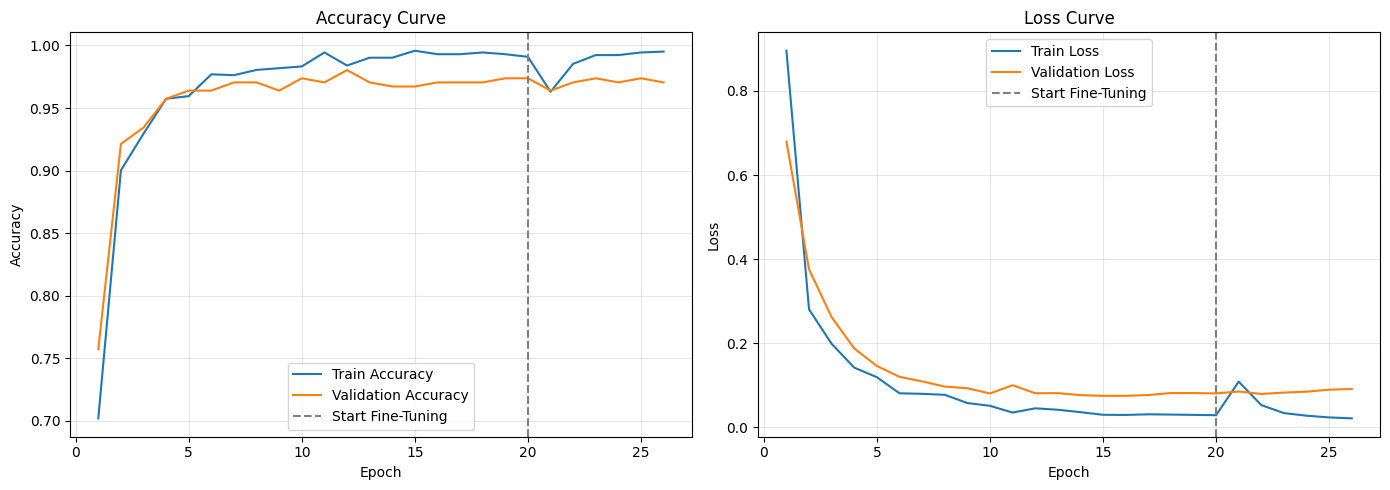

In [11]:
def combine_histories(first_history, second_history):
    combined = {}
    for key in first_history.history:
        combined[key] = first_history.history[key] + second_history.history.get(key, [])
    return combined

history = combine_histories(history_stage_1, history_stage_2)
epochs_range = range(1, len(history['loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['accuracy'], label='Train Accuracy')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy')
plt.axvline(len(history_stage_1.history['loss']), color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.axvline(len(history_stage_1.history['loss']), color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Evaluate the Best Model on the Test Set

In [12]:
best_model = keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds_prepared, verbose=1)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9744 - loss: 0.0653
Test loss: 0.0653
Test accuracy: 0.9744


## 12. Classification Report and Confusion Matrix

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
Classification Report
                 precision    recall  f1-score   support

Algal leaf spot       0.98      1.00      0.99        47
     Black spot       0.98      0.98      0.98        51
  Citrus canker       0.96      0.93      0.95        56
    Citrus pest       0.95      1.00      0.98        59
       Greening       0.98      0.94      0.96        54
   Healthy leaf       1.00      1.00      1.00        45

       accuracy                           0.97       312
      macro avg       0.98      0.98      0.98       312
   weighted avg       0.97      0.97      0.97       312



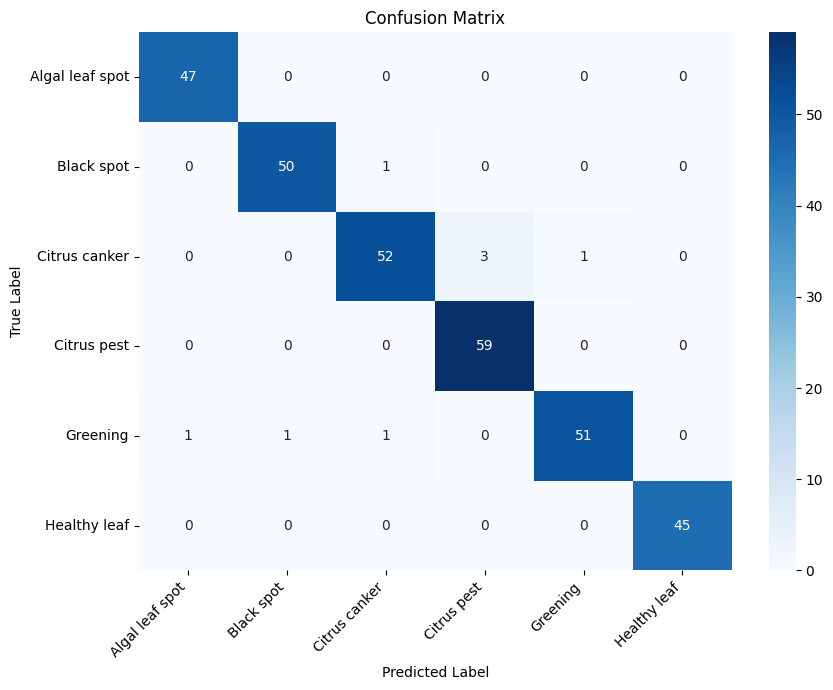

In [13]:
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds], axis=0)
y_prob = best_model.predict(test_ds_prepared, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print('Classification Report')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Saved Outputs

After the notebook runs successfully:

- Best model: `model/resnet_best_model.keras`
- Class index mapping: `training/class_indices.json`